In [1]:
from pathlib import Path
import pandas as pd

base = Path("/Users/andrewgerardo/Bellabeat/Raw_Data")

In [2]:
daily_files = list(base.rglob("dailyActivity_merged.csv"))
sleep_files = list(base.rglob("sleepDay_merged.csv"))
weight_files = list(base.rglob("weightLogInfo_merged.csv"))

print("Daily files:", daily_files)
print("Sleep files:", sleep_files)
print("Weight files:", weight_files)

Daily files: [PosixPath('/Users/andrewgerardo/Bellabeat/Raw_Data/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/dailyActivity_merged.csv'), PosixPath('/Users/andrewgerardo/Bellabeat/Raw_Data/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv')]
Sleep files: [PosixPath('/Users/andrewgerardo/Bellabeat/Raw_Data/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv')]
Weight files: [PosixPath('/Users/andrewgerardo/Bellabeat/Raw_Data/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/weightLogInfo_merged.csv'), PosixPath('/Users/andrewgerardo/Bellabeat/Raw_Data/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/weightLogInfo_merged.csv')]


In [3]:
daily_activity = pd.concat(
    [pd.read_csv(file) for file in daily_files],
    ignore_index=True
)

sleep_day = pd.concat(
    [pd.read_csv(file) for file in sleep_files],
    ignore_index=True
)

weight_log = pd.concat(
    [pd.read_csv(file) for file in weight_files],
    ignore_index=True
)

In [4]:
print("Daily Activity:", daily_activity.shape)
print("Sleep Day:", sleep_day.shape)
print("Weight Log:", weight_log.shape)

Daily Activity: (1397, 15)
Sleep Day: (413, 5)
Weight Log: (100, 8)


In [5]:
sleep_day = sleep_day.drop_duplicates()
weight_log = weight_log.drop_duplicates()

daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'])
sleep_day['SleepDay'] = pd.to_datetime(sleep_day['SleepDay'])
weight_log['Date'] = pd.to_datetime(weight_log['Date'])

if 'Fat' in weight_log.columns:
    weight_log = weight_log.drop(columns=['Fat'])

daily_activity['DayOfWeek'] = daily_activity['ActivityDate'].dt.day_name()
sleep_day['DayOfWeek'] = sleep_day['SleepDay'].dt.day_name()
weight_log['DayOfWeek'] = weight_log['Date'].dt.day_name()

/var/folders/z7/4dcbhsys3n169ss2n8h8bcdw0000gn/T/ipykernel_1648/1676461470.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep_day['SleepDay'] = pd.to_datetime(sleep_day['SleepDay'])
/var/folders/z7/4dcbhsys3n169ss2n8h8bcdw0000gn/T/ipykernel_1648/1676461470.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weight_log['Date'] = pd.to_datetime(weight_log['Date'])


In [6]:
daily_activity.describe()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,1.397000e+03,1397,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000
mean,4.781210e+09,2016-04-19 01:26:35.132426496,7280.898354,5.219434,5.192219,0.131481,1.397416,0.538461,3.193407,0.001704,19.679313,13.403006,185.372942,992.542591,2266.265569
min,1.503960e+09,2016-03-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,2016-04-09 00:00:00,3146.000000,2.170000,2.160000,0.000000,0.000000,0.000000,1.610000,0.000000,0.000000,0.000000,111.000000,729.000000,1799.000000
50%,4.445115e+09,2016-04-19 00:00:00,6999.000000,4.950000,4.950000,0.000000,0.100000,0.200000,3.240000,0.000000,2.000000,6.000000,195.000000,1057.000000,2114.000000
75%,6.962181e+09,2016-04-30 00:00:00,10544.000000,7.500000,7.480000,0.000000,1.830000,0.770000,4.690000,0.000000,30.000000,18.000000,262.000000,1244.000000,2770.000000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,28.030001,28.030001,6.727057,21.920000,6.480000,12.510000,0.110000,210.000000,660.000000,720.000000,1440.000000,4900.000000
std,2.384293e+09,NaN,5214.336113,3.994206,3.980077,0.703683,2.607480,0.867436,2.116869,0.007736,31.675878,26.401247,114.058601,313.297376,753.005527


In [7]:
sleep_day.describe()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,4.100000e+02,410,410.000000,410.000000,410.000000
mean,4.994963e+09,2016-04-26 11:38:55.609756160,1.119512,419.173171,458.482927
min,1.503960e+09,2016-04-12 00:00:00,1.000000,58.000000,61.000000
25%,3.977334e+09,2016-04-19 00:00:00,1.000000,361.000000,403.750000
50%,4.702922e+09,2016-04-27 00:00:00,1.000000,432.500000,463.000000
75%,6.962181e+09,2016-05-04 00:00:00,1.000000,490.000000,526.000000
max,8.792010e+09,2016-05-12 00:00:00,3.000000,796.000000,961.000000
std,2.060863e+09,NaN,0.346636,118.635918,127.455140


In [8]:
user_activity = daily_activity.groupby('Id').agg({
    'TotalSteps': 'mean',
    'Calories': 'mean',
    'VeryActiveMinutes': 'mean',
    'FairlyActiveMinutes': 'mean',
    'LightlyActiveMinutes': 'mean',
    'SedentaryMinutes': 'mean'
}).reset_index()

user_activity.head()

,Id,TotalSteps,Calories,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes
0,1503960366,11935.780000,1808.740000,37.620000,17.900000,223.080000,833.600000
1,1624580081,5167.200000,1433.780000,5.660000,3.820000,141.160000,1265.560000
2,1644430081,7780.925000,2837.575000,10.875000,26.900000,190.775000,1129.950000
3,1844505072,2876.023256,1585.325581,0.302326,1.139535,127.465116,1158.813953
4,1927972279,1269.069767,2195.465116,0.953488,1.023256,58.976744,1215.697674


In [9]:
user_sleep = sleep_day.groupby('Id').agg({
    'TotalMinutesAsleep': 'mean',
    'TotalTimeInBed': 'mean'
}).reset_index()

user_sleep.head()

,Id,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,360.280000,383.200000
1,1644430081,294.000000,346.000000
2,1844505072,652.000000,961.000000
3,1927972279,417.000000,437.800000
4,2026352035,506.178571,537.642857


In [10]:
activity_by_day = daily_activity.groupby('DayOfWeek').agg({
    'TotalSteps': 'mean',
    'Calories': 'mean',
    'VeryActiveMinutes': 'mean',
    'SedentaryMinutes': 'mean'
}).reset_index()

In [11]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

activity_by_day['DayOfWeek'] = pd.Categorical(
    activity_by_day['DayOfWeek'],
    categories=day_order,
    ordered=True
)

activity_by_day = activity_by_day.sort_values('DayOfWeek')

activity_by_day

,DayOfWeek,TotalSteps,Calories,VeryActiveMinutes,SedentaryMinutes
1,Monday,7541.319149,2298.404255,21.606383,1029.718085
5,Tuesday,7083.511111,2156.937778,19.773333,956.386667
6,Wednesday,7547.575758,2320.762626,19.858586,994.712121
4,Thursday,7268.297436,2223.753846,18.923077,984.902564
0,Friday,7187.532663,2325.095477,18.567839,1020.266332
2,Saturday,7752.271357,2325.804020,20.809045,968.934673
3,Sunday,6606.725389,2227.409326,18.253886,999.730570


In [12]:
sleep_by_day = sleep_day.groupby('DayOfWeek').agg({
    'TotalMinutesAsleep':'mean',
    'TotalTimeInBed':'mean'
}).reset_index()

sleep_by_day['DayOfWeek'] = pd.Categorical(
    sleep_by_day['DayOfWeek'],
    categories=day_order,
    ordered=True
)

sleep_by_day = sleep_by_day.sort_values('DayOfWeek')

sleep_by_day

,DayOfWeek,TotalMinutesAsleep,TotalTimeInBed
1,Monday,419.500000,457.347826
5,Tuesday,404.538462,443.292308
6,Wednesday,434.681818,470.030303
4,Thursday,401.296875,434.875000
0,Friday,405.421053,445.052632
2,Saturday,419.070175,459.842105
3,Sunday,452.745455,503.509091


In [13]:
print("Average Steps:",
      round(daily_activity['TotalSteps'].mean(),2))

Average Steps: 7280.9


In [14]:
print("Average Calories:",
      round(daily_activity['Calories'].mean(),2))

Average Calories: 2266.27


In [15]:
print("Average Sedentary Minutes:",
      round(daily_activity['SedentaryMinutes'].mean(),2))

Average Sedentary Minutes: 992.54


In [16]:
avg_sleep = sleep_day['TotalMinutesAsleep'].mean()

print("Average Sleep Hours:",
      round(avg_sleep/60,2))

Average Sleep Hours: 6.99


In [17]:
activity_sleep = user_activity.merge(
    user_sleep,
    on='Id',
    how='inner'
)

activity_sleep.head()

,Id,TotalSteps,Calories,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,11935.780000,1808.740000,37.620000,17.900000,223.080000,833.600000,360.280000,383.200000
1,1644430081,7780.925000,2837.575000,10.875000,26.900000,190.775000,1129.950000,294.000000,346.000000
2,1844505072,2876.023256,1585.325581,0.302326,1.139535,127.465116,1158.813953,652.000000,961.000000
3,1927972279,1269.069767,2195.465116,0.953488,1.023256,58.976744,1215.697674,417.000000,437.800000
4,2026352035,4960.139535,1488.976744,0.069767,0.186047,232.279070,680.976744,506.178571,537.642857


In [18]:
activity_sleep[['TotalSteps',
                'TotalMinutesAsleep']].corr()

,TotalSteps,TotalMinutesAsleep
TotalSteps,1.000000,-0.222298
TotalMinutesAsleep,-0.222298,1.000000


In [19]:
def activity_level(steps):
    if steps < 5000:
        return "Low Activity"
    elif steps < 10000:
        return "Moderate Activity"
    else:
        return "High Activity"

daily_activity['ActivityLevel'] = daily_activity['TotalSteps'].apply(activity_level)

In [20]:
daily_activity['ActivityLevel'].value_counts()

ActivityLevel
Low Activity         500
Moderate Activity    467
High Activity        430
Name: count, dtype: int64

In [21]:
sleep_activity = daily_activity.merge(
    sleep_day,
    left_on=['Id', 'ActivityDate'],
    right_on=['Id', 'SleepDay'],
    how='inner'
)

In [22]:
sleep_by_activity = sleep_activity.groupby('ActivityLevel').agg({
    'TotalMinutesAsleep':'mean',
    'TotalSteps':'mean'
}).reset_index()

sleep_by_activity

,ActivityLevel,TotalMinutesAsleep,TotalSteps
0,High Activity,396.060606,12526.375758
1,Low Activity,453.943925,2828.037383
2,Moderate Activity,421.766667,7579.986667


In [23]:
user_activity.to_csv("user_activity_summary.csv", index=False)
user_sleep.to_csv("user_sleep_summary.csv", index=False)
activity_by_day.to_csv("activity_by_day_summary.csv", index=False)
sleep_by_day.to_csv("sleep_by_day_summary.csv", index=False)
activity_sleep.to_csv("activity_sleep_summary.csv", index=False)
sleep_by_activity.to_csv("sleep_by_activity_summary.csv", index=False)

In [24]:
activity_by_day = daily_activity.groupby('DayOfWeek').agg({
    'TotalSteps': 'mean',
    'Calories': 'mean',
    'VeryActiveMinutes': 'mean',
    'SedentaryMinutes': 'mean'
}).reset_index()

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

activity_by_day['DayOfWeek'] = pd.Categorical(
    activity_by_day['DayOfWeek'],
    categories=day_order,
    ordered=True
)

activity_by_day = activity_by_day.sort_values('DayOfWeek')

activity_by_day

,DayOfWeek,TotalSteps,Calories,VeryActiveMinutes,SedentaryMinutes
1,Monday,7541.319149,2298.404255,21.606383,1029.718085
5,Tuesday,7083.511111,2156.937778,19.773333,956.386667
6,Wednesday,7547.575758,2320.762626,19.858586,994.712121
4,Thursday,7268.297436,2223.753846,18.923077,984.902564
0,Friday,7187.532663,2325.095477,18.567839,1020.266332
2,Saturday,7752.271357,2325.804020,20.809045,968.934673
3,Sunday,6606.725389,2227.409326,18.253886,999.730570


In [25]:
sleep_by_day = sleep_day.groupby('DayOfWeek').agg({
    'TotalMinutesAsleep': 'mean',
    'TotalTimeInBed': 'mean'
}).reset_index()

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

sleep_by_day['DayOfWeek'] = pd.Categorical(
    sleep_by_day['DayOfWeek'],
    categories=day_order,
    ordered=True
)

sleep_by_day = sleep_by_day.sort_values('DayOfWeek')

sleep_by_day

,DayOfWeek,TotalMinutesAsleep,TotalTimeInBed
1,Monday,419.500000,457.347826
5,Tuesday,404.538462,443.292308
6,Wednesday,434.681818,470.030303
4,Thursday,401.296875,434.875000
0,Friday,405.421053,445.052632
2,Saturday,419.070175,459.842105
3,Sunday,452.745455,503.509091


In [26]:
user_activity = daily_activity.groupby('Id').agg({
    'TotalSteps': 'mean',
    'Calories': 'mean',
    'VeryActiveMinutes': 'mean',
    'FairlyActiveMinutes': 'mean',
    'LightlyActiveMinutes': 'mean',
    'SedentaryMinutes': 'mean'
}).reset_index()

user_sleep = sleep_day.groupby('Id').agg({
    'TotalMinutesAsleep': 'mean',
    'TotalTimeInBed': 'mean'
}).reset_index()

activity_sleep = user_activity.merge(
    user_sleep,
    on='Id',
    how='inner'
)

activity_sleep[['TotalSteps', 'TotalMinutesAsleep']].corr()

,TotalSteps,TotalMinutesAsleep
TotalSteps,1.000000,-0.222298
TotalMinutesAsleep,-0.222298,1.000000


In [27]:
activity_level_counts = (
    daily_activity['ActivityLevel']
    .value_counts()
    .reset_index()
)

activity_level_counts.columns = ['ActivityLevel', 'Count']

activity_level_counts

,ActivityLevel,Count
0,Low Activity,500
1,Moderate Activity,467
2,High Activity,430


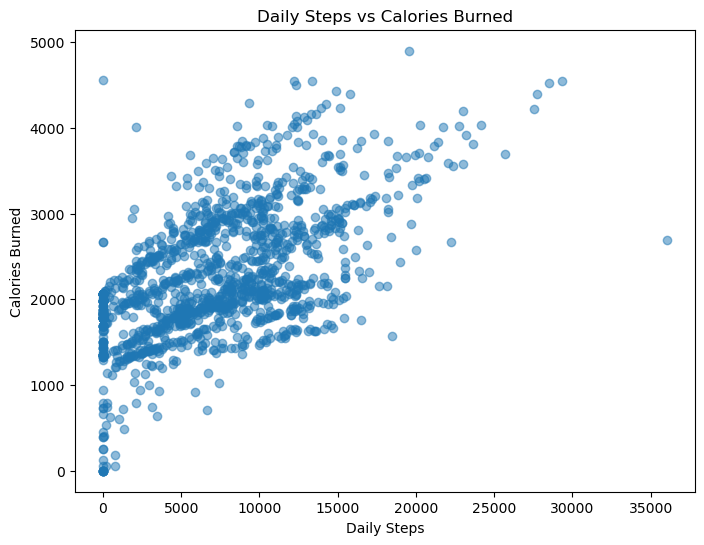

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    daily_activity['TotalSteps'],
    daily_activity['Calories'],
    alpha=0.5
)

plt.title('Daily Steps vs Calories Burned')
plt.xlabel('Daily Steps')
plt.ylabel('Calories Burned')

plt.show()

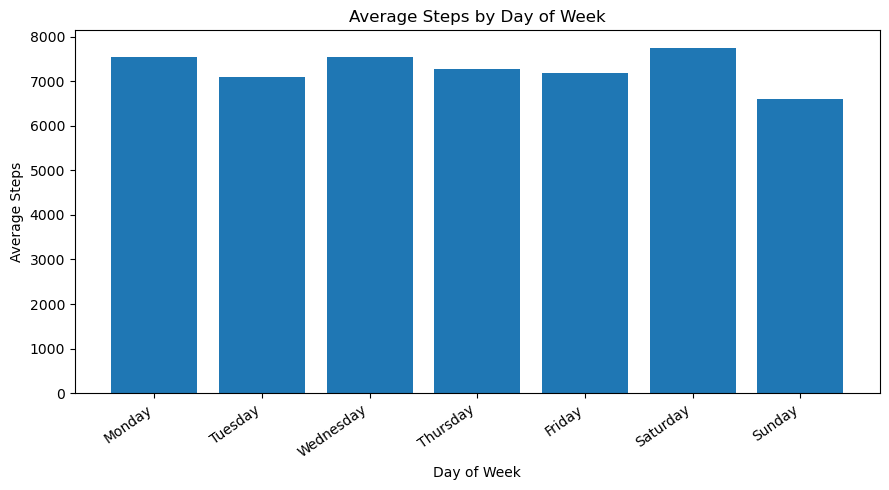

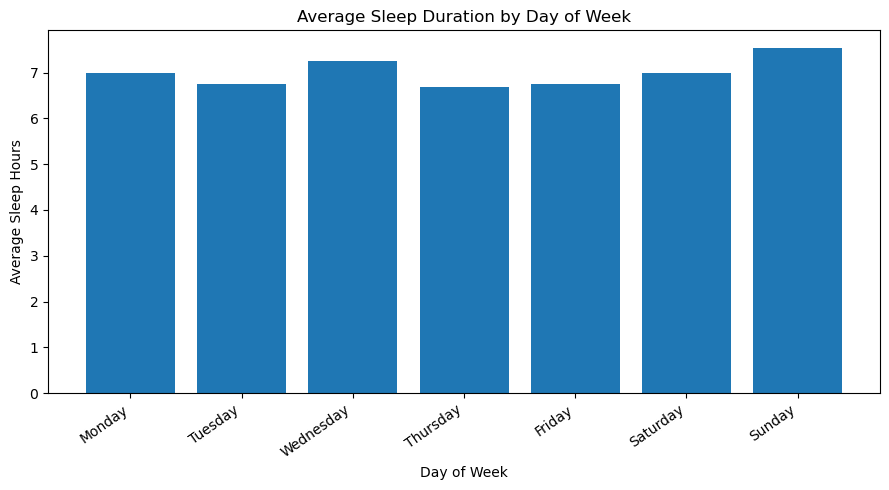

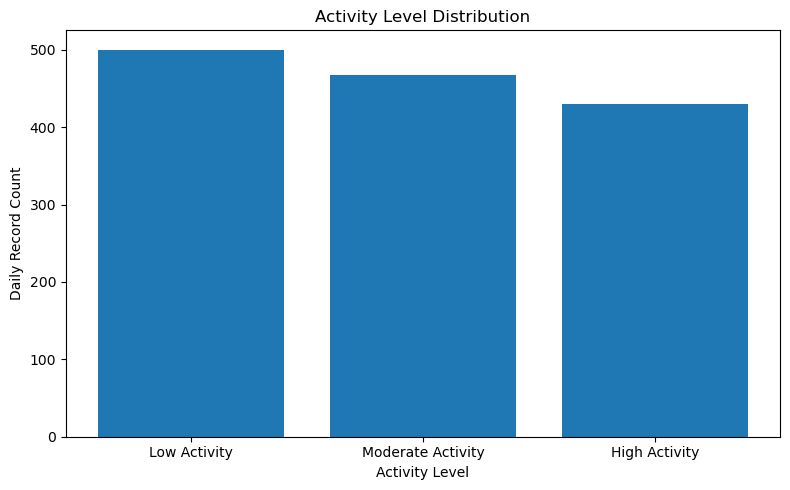

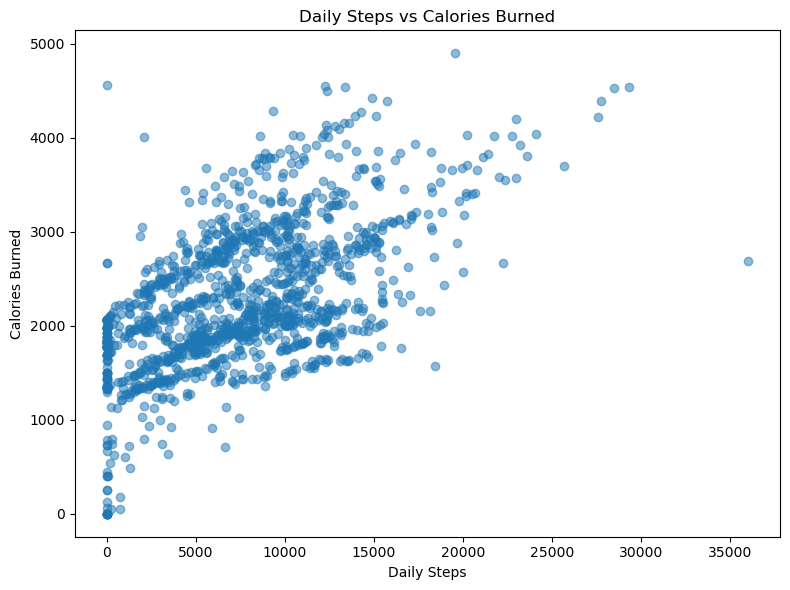

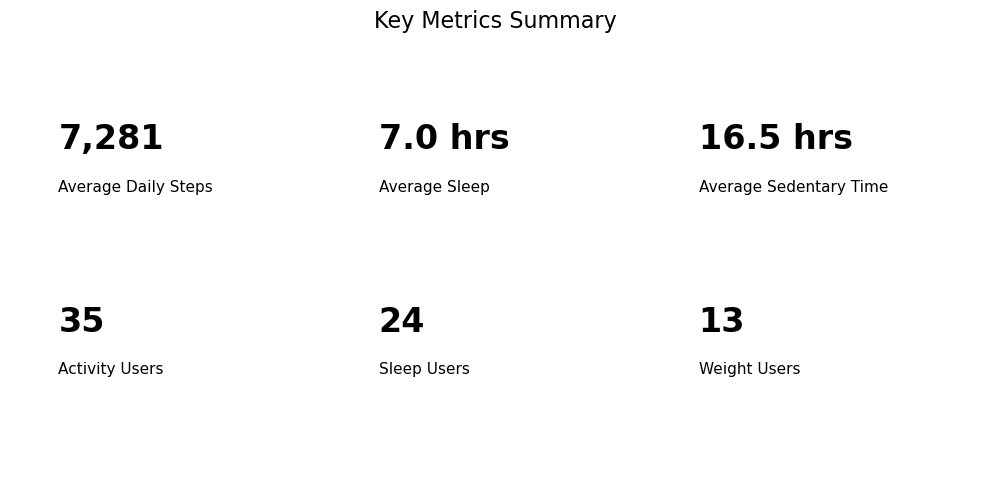

Visualizations saved to: /Users/andrewgerardo/Bellabeat/Visualizations


In [29]:
# Bellabeat Visualization Code
# Run this after your cleaned datasets and analysis tables exist in Jupyter:
# daily_activity, sleep_day, activity_by_day, sleep_by_day

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# Create Visualizations folder
visuals_dir = Path('/Users/andrewgerardo/Bellabeat/Visualizations')
visuals_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1. Average Steps by Day of Week
# -----------------------------
plt.figure(figsize=(9, 5))
plt.bar(activity_by_day['DayOfWeek'].astype(str), activity_by_day['TotalSteps'])
plt.title('Average Steps by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Steps')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(visuals_dir / 'average_steps_by_day.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# 2. Average Sleep Duration by Day of Week
# -----------------------------
sleep_by_day = sleep_by_day.copy()
sleep_by_day['SleepHours'] = sleep_by_day['TotalMinutesAsleep'] / 60

plt.figure(figsize=(9, 5))
plt.bar(sleep_by_day['DayOfWeek'].astype(str), sleep_by_day['SleepHours'])
plt.title('Average Sleep Duration by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sleep Hours')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(visuals_dir / 'average_sleep_by_day.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# 3. Activity Level Distribution
# -----------------------------
# Create ActivityLevel if it does not already exist
if 'ActivityLevel' not in daily_activity.columns:
    def activity_level(steps):
        if steps < 5000:
            return 'Low Activity'
        elif steps < 10000:
            return 'Moderate Activity'
        else:
            return 'High Activity'

    daily_activity['ActivityLevel'] = daily_activity['TotalSteps'].apply(activity_level)

activity_level_counts = (
    daily_activity['ActivityLevel']
    .value_counts()
    .reindex(['Low Activity', 'Moderate Activity', 'High Activity'])
    .reset_index()
)
activity_level_counts.columns = ['ActivityLevel', 'Count']

plt.figure(figsize=(8, 5))
plt.bar(activity_level_counts['ActivityLevel'], activity_level_counts['Count'])
plt.title('Activity Level Distribution')
plt.xlabel('Activity Level')
plt.ylabel('Daily Record Count')
plt.tight_layout()
plt.savefig(visuals_dir / 'activity_level_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# 4. Steps vs Calories Burned
# -----------------------------
plt.figure(figsize=(8, 6))
plt.scatter(daily_activity['TotalSteps'], daily_activity['Calories'], alpha=0.5)
plt.title('Daily Steps vs Calories Burned')
plt.xlabel('Daily Steps')
plt.ylabel('Calories Burned')
plt.tight_layout()
plt.savefig(visuals_dir / 'steps_vs_calories.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# 5. Key Metrics Summary
# -----------------------------
metrics = {
    'Average Daily Steps': f"{daily_activity['TotalSteps'].mean():,.0f}",
    'Average Sleep': f"{sleep_day['TotalMinutesAsleep'].mean() / 60:.1f} hrs",
    'Average Sedentary Time': f"{daily_activity['SedentaryMinutes'].mean() / 60:.1f} hrs",
    'Activity Users': f"{daily_activity['Id'].nunique()}",
    'Sleep Users': f"{sleep_day['Id'].nunique()}",
    'Weight Users': f"{weight_log['Id'].nunique()}" if 'weight_log' in globals() else '13'
}

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

x_positions = [0.05, 0.38, 0.71, 0.05, 0.38, 0.71]
y_positions = [0.68, 0.68, 0.68, 0.25, 0.25, 0.25]

for (label, value), x, y in zip(metrics.items(), x_positions, y_positions):
    ax.text(x, y + 0.1, value, fontsize=24, fontweight='bold', transform=ax.transAxes)
    ax.text(x, y, label, fontsize=11, transform=ax.transAxes)

plt.title('Key Metrics Summary', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(visuals_dir / 'key_metrics_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Visualizations saved to: {visuals_dir}')
